# Subsequent EDA for Spotify Listening History Data
---
**Goal:**
- Build on the cleaned datasets, with focus on deeper exploratory analysis
- Identify behavioral patterns and trends

**Tasks:**

0. Load & review cleaning
1. Subsequent EDA & observations
2. Visuals

In [38]:
#Load
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load & Last Cleaning
---
Outputs: 

**User A:**
- Shape: (136,382, 13)
- Time range: 2021-11-03 18:04:27 to 2025-08-04 19:57:08
- Missing values:
  - `offline_timestamp`: 7,343 (~5%)
  - All other columns complete

**User B:**
- Shape: (60,357, 13)
- Time range: 2021-11-03 18:15:30 to 2025-08-04 19:59:02
- Missing values:
  - `offline_timestamp`: 34,005 (~56%)
  - All other columns complete

**Notes:**
- Both datasets are aligned over the overlapping period
- Boolean columns (`shuffle`, `skipped`, `offline`, `incognito_mode`) standardized
- Ready for exploratory analysis

In [39]:
#Load cleaned datasets
df_a = pd.read_csv("../Cleaned Data/User_A_Cleaned_Aligned_2021-2025.csv", low_memory=False)
df_b = pd.read_csv("../Cleaned Data/User_B_Cleaned_Aligned_2021-2025.csv", low_memory=False)

#Quick check
df_a.head(), df_b.head()

(                          ts  ms_played  \
 0  2021-11-03 18:04:27+00:00       4840   
 1  2021-11-03 18:04:33+00:00       5530   
 2  2021-11-03 18:04:40+00:00       6510   
 3  2021-11-03 18:05:00+00:00      19430   
 4  2021-11-03 18:05:11+00:00       8700   
 
                  master_metadata_track_name master_metadata_album_artist_name  \
 0  Wish Me Luck (Extended Explicit Version)                           50 Cent   
 1                                In My Hood                           50 Cent   
 2                                This Is 50                           50 Cent   
 3                                Piggy Bank                           50 Cent   
 4                           What Up Gangsta                           50 Cent   
 
            master_metadata_album_album_name  \
 0  Wish Me Luck (Extended Explicit Version)   
 1                              The Massacre   
 2                              The Massacre   
 3                              The Massacre   


In [40]:
#Parse timestamp (again)
for df in [df_a, df_b]:
    df['ts'] = pd.to_datetime(df['ts'], utc=True)

In [41]:
#Review
print("User A shape:", df_a.shape, "User B shape:", df_b.shape)
print("User A time range:", df_a['ts'].min(), "to", df_a['ts'].max())
print("User B time range:", df_b['ts'].min(), "to", df_b['ts'].max())
print("User A missing values:\n", df_a.isnull().sum())
print("User B missing values:\n", df_b.isnull().sum())

User A shape: (136517, 20) User B shape: (60383, 20)
User A time range: 2021-11-03 18:04:27+00:00 to 2025-08-04 19:57:08+00:00
User B time range: 2021-11-03 18:15:30+00:00 to 2025-08-04 19:59:02+00:00
User A missing values:
 ts                                        0
ms_played                                 0
master_metadata_track_name              135
master_metadata_album_artist_name       135
master_metadata_album_album_name        135
spotify_track_uri                       135
episode_name                         136385
episode_show_name                    136385
spotify_episode_uri                  136385
audiobook_title                      136514
audiobook_uri                        136514
audiobook_chapter_uri                136514
audiobook_chapter_title              136515
reason_start                              0
reason_end                                0
shuffle                                   0
skipped                                   0
offline                    

In [42]:
#Drop rows with missing track info
for df in [df_a, df_b]:
    df.dropna(subset=['master_metadata_track_name', 
                      'master_metadata_album_artist_name', 
                      'master_metadata_album_album_name', 
                      'spotify_track_uri'], inplace=True)
    
#Drop podcast/audiobook columns (mostly NaN)
cols_to_drop = [
    'episode_name', 'episode_show_name', 'spotify_episode_uri',
    'audiobook_title', 'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title'
]
for df in [df_a, df_b]:
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

#Convert booleans properly
for df in [df_a, df_b]:
    df['shuffle'] = df['shuffle'].astype(bool)
    df['skipped'] = df['skipped'].astype(bool)
    df['offline'] = df['offline'].astype(bool)
    df['incognito_mode'] = df['incognito_mode'].astype(bool)
    # offline_timestamp numeric
    df['offline_timestamp'] = pd.to_numeric(df['offline_timestamp'], errors='coerce')

#Ensure timestamp is dt
for df in [df_a, df_b]:
    df['ts'] = pd.to_datetime(df['ts'], utc=True)

#Quick sanity check
for name, df in zip(['User A', 'User B'], [df_a, df_b]):
    print(name, "shape:", df.shape)
    print(name, "time range:", df['ts'].min(), "to", df['ts'].max())
    print(name, "missing values:\n", df.isnull().sum())
    print("-"*40)

User A shape: (136382, 13)
User A time range: 2021-11-03 18:04:27+00:00 to 2025-08-04 19:57:08+00:00
User A missing values:
 ts                                      0
ms_played                               0
master_metadata_track_name              0
master_metadata_album_artist_name       0
master_metadata_album_album_name        0
spotify_track_uri                       0
reason_start                            0
reason_end                              0
shuffle                                 0
skipped                                 0
offline                                 0
offline_timestamp                    7343
incognito_mode                          0
dtype: int64
----------------------------------------
User B shape: (60357, 13)
User B time range: 2021-11-03 18:15:30+00:00 to 2025-08-04 19:59:02+00:00
User B missing values:
 ts                                       0
ms_played                                0
master_metadata_track_name               0
master_metadata_album_

In [43]:
#Save for clean setup
df_a.to_csv("../Cleaned Data/User_A_FE_Ready.csv", index=False)
df_b.to_csv("../Cleaned Data/User_B_FE_Ready.csv", index=False)

# Section 1-4 | Subsequent EDA
---

## Section 1 | Aggregate Listening Metrics
---

In [44]:
#Total listening time (minutes) per user
total_minutes_a = df_a['ms_played'].sum() / 60000
total_minutes_b = df_b['ms_played'].sum() / 60000

#Average track duration (minutes)
avg_track_a = df_a['ms_played'].mean() / 60000
avg_track_b = df_b['ms_played'].mean() / 60000

#Total number of tracks
num_tracks_a = df_a.shape[0]
num_tracks_b = df_b.shape[0]

print(f"User A: {total_minutes_a:.0f} min total, {avg_track_a:.2f} min avg track, {num_tracks_a} tracks")
print(f"User B: {total_minutes_b:.0f} min total, {avg_track_b:.2f} min avg track, {num_tracks_b} tracks")

User A: 314526 min total, 2.31 min avg track, 136382 tracks
User B: 60226 min total, 1.00 min avg track, 60357 tracks


## Section 2 | Top 10 Artists, Tracks & Albums
---

In [45]:
#Top 10 [subject] by play count

#Tracks
top_tracks_a = df_a['master_metadata_track_name'].value_counts().head(10)
top_tracks_b = df_b['master_metadata_track_name'].value_counts().head(10)

#Artists
top_artists_a = df_a['master_metadata_album_artist_name'].value_counts().head(10)
top_artists_b = df_b['master_metadata_album_artist_name'].value_counts().head(10)

#Albums
top_albums_a = df_a['master_metadata_album_album_name'].value_counts().head(10)
top_albums_b = df_b['master_metadata_album_album_name'].value_counts().head(10)

print("User A Top Tracks:\n", top_tracks_a)
print("\nUser B Top Tracks:\n", top_tracks_b)

User A Top Tracks:
 master_metadata_track_name
Heartless (feat. Mustard)                           1492
Armed And Dangerous                                  860
Smile                                                801
My Fault                                             567
Scared Of Love (with instrumental by Ghost Loft)     562
Empty                                                471
All Girls Are The Same                               443
Hit 'Em Up - Single Version                          437
Ambitionz Az A Ridah                                 419
Breathin                                             418
Name: count, dtype: int64

User B Top Tracks:
 master_metadata_track_name
All Girls Are The Same         531
Grabba Leaf                    366
Empty                          358
When the Drugs Don't Work      349
Robbery                        328
Nikki Sixx                     325
Already Dead                   316
Lucid Dreams                   311
Hate Song                    

## Section 3 | Time-Based Analysis
---

In [46]:
#Extract dt components
for df in [df_a, df_b]:
    df['year'] = df['ts'].dt.year
    df['month'] = df['ts'].dt.month
    df['day_of_week'] = df['ts'].dt.day_name()
    df['hour'] = df['ts'].dt.hour

#Listening per year (minutes)
listening_year_a = df_a.groupby('year')['ms_played'].sum() / 60000
listening_year_b = df_b.groupby('year')['ms_played'].sum() / 60000

print("User A listening per year:\n", listening_year_a)
print("\nUser B listening per year:\n", listening_year_b)

User A listening per year:
 year
2021      1627.435067
2022     29913.933267
2023    126775.968150
2024     80768.858350
2025     75439.974067
Name: ms_played, dtype: float64

User B listening per year:
 year
2021     9738.289450
2022    33874.458217
2023     9118.872450
2024     6490.138517
2025     1004.033000
Name: ms_played, dtype: float64


## Section 4 | Behavior Metrics
---

In [47]:
#Percent of tracks shuffled, skipped, offline
for user, df in zip(['User A','User B'], [df_a, df_b]):
    shuffle_pct = df['shuffle'].mean() * 100
    skipped_pct = df['skipped'].mean() * 100
    offline_pct = df['offline'].mean() * 100
    print(f"{user} - Shuffle: {shuffle_pct:.1f}%, Skipped: {skipped_pct:.1f}%, Offline: {offline_pct:.1f}%")

User A - Shuffle: 74.2%, Skipped: 42.5%, Offline: 1.5%
User B - Shuffle: 50.8%, Skipped: 35.9%, Offline: 0.5%


## Section 1-4 | Subsequent EDA
---
### **1. Listening Volume Overview:**
---
|Metric	                   | User A	 | User B |
|--------------------------|---------|--------|
|Total listening time (min)| 314,526 | 60,226 |
|Average track length (min)| 2.31	 | 1.00   |
|Total tracks	           | 136,382 | 60,357 |

**Insight:** User A listens significantly more than User B, with longer average track durations.

### **2. Top Tracks:**
---
User A Top 10 Tracks:
 1. Heartless (feat. Mustard) – 1,492 plays
 2. Armed And Dangerous – 860 plays
 3. Smile – 801 plays
 4. My Fault – 567 plays
 5. Scared Of Love (with instrumental by Ghost Loft) – 562 plays

User B Top 10 Tracks:
 1. All Girls Are The Same – 531 plays
 2. Grabba Leaf – 366 plays
 3. Empty – 358 plays
 4. When the Drugs Don't Work – 349 plays
 5. Robbery – 328 plays

**Insight** Some overlap exists (e.g., All Girls Are The Same, Empty), but each user has distinct favorites.

### **3. Listening Over Time:**
---
|Year | User A	 | User B |
|-----|------------|--------|
|2021 | 1,627      | 9,738  |
|2022 | 29,914     | 33,874 |
|2023 | 126,776    | 9,119  |
|2024 | 80,769     | 6,490  |
|2025 | 75,440     | 1,004  |

**Insight:** User A’s listening peaks in 2023, while User B had the most listening in 2022. User B’s listening drops drastically after 2022.

### **4. Behavior Metrics**
---
|Metric | User A  | User B |
|-------|---------|--------|
|Shuffle| 74.2%   | 50.8%  |
|Skipped| 42.5%   | 35.9%  |
|Offline| 1.5%    | 0.5%   |

**Insight:**
- User A shuffles tracks more often and skips more frequently, suggesting a more exploratory or fast-paced listening style.
- Both users rarely listen offline, though User A slightly more than User B

## Visualizations
---
1. Monthly Listening Mins
   - User A has consistently higher total minutes
   - While User B shows lower listening with a few spikes.

We can see overall trends and peaks in listening activity over time.

2. Top 10 Tracks
   - User A’s most played tracks include "Heartless" and "Armed And Dangerous"
   - While User B’s top tracks include "All Girls Are The Same" and "Grabba Leaf".

This gives insight into the users’ favorite songs.

3. Top 10 Artists
   - User A favors artists like 50 Cent and Juice WRLD
   - User B also listens heavily to Juice WRLD and similar artists.

We can compare musical taste across users.

4. Track Listening Duration
   - User A tends to listen to slightly longer tracks on average (2–3 min)
   - Compared to User B (1 min)

5. Temporal Patterns
   - User A tends to listen heavily in the evenings, with peaks on certain weekdays
   - While User B’s listening is more sporadic.

This gives insight into daily and weekly listening habits. (Darker cells represent more minutes played)

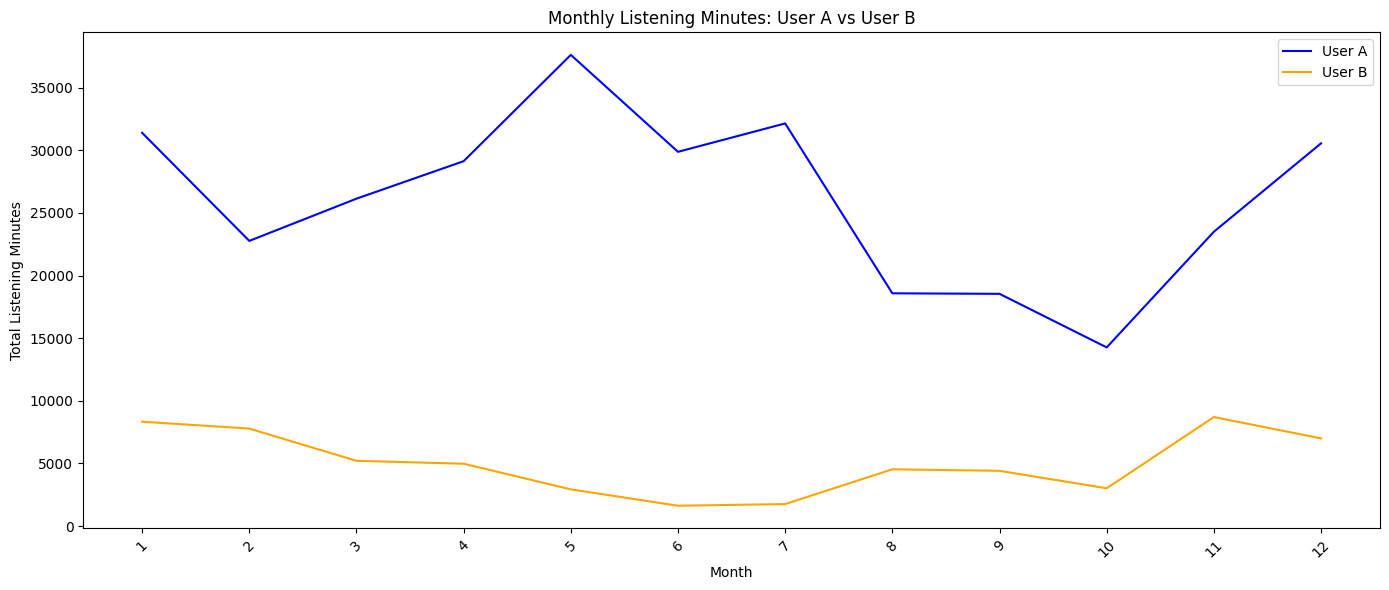

In [48]:
#Listening Over Time
#Aggregate total minutes per month
df_a_monthly = df_a.groupby('month')['ms_played'].sum() / 60000
df_b_monthly = df_b.groupby('month')['ms_played'].sum() / 60000

#Plot
plt.figure(figsize=(14,6))
plt.plot(df_a_monthly.index.astype(str), df_a_monthly.values, label='User A', color='blue')
plt.plot(df_b_monthly.index.astype(str), df_b_monthly.values, label='User B', color='orange')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Listening Minutes")
plt.title("Monthly Listening Minutes: User A vs User B")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\lynnm\AppData\Local\Temp\ipykernel_1596\3287892789.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tracks_a.values, y=top_tracks_a.index, palette='Blues_r')


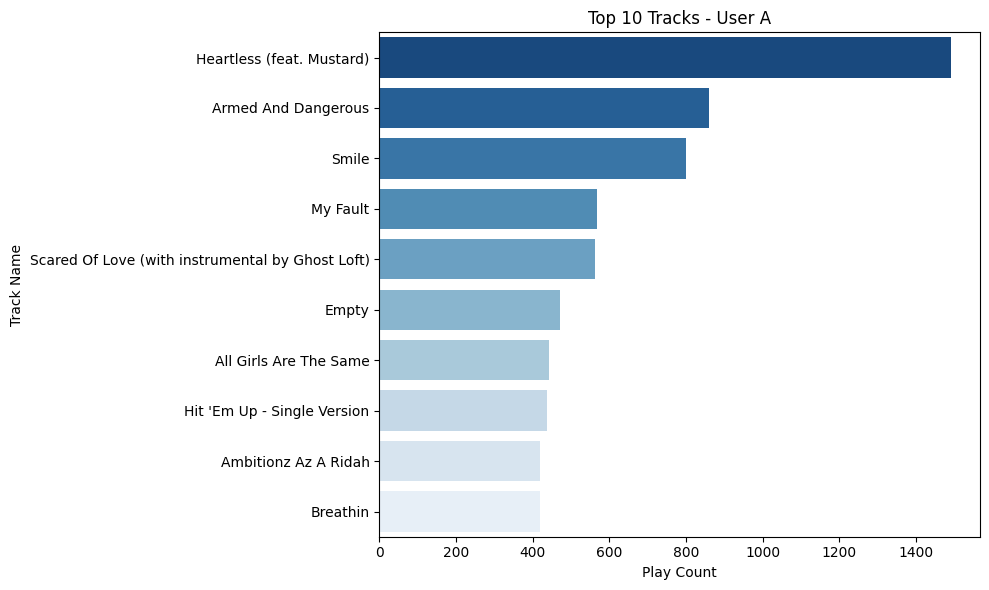

C:\Users\lynnm\AppData\Local\Temp\ipykernel_1596\3287892789.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tracks_b.values, y=top_tracks_b.index, palette='Oranges_r')


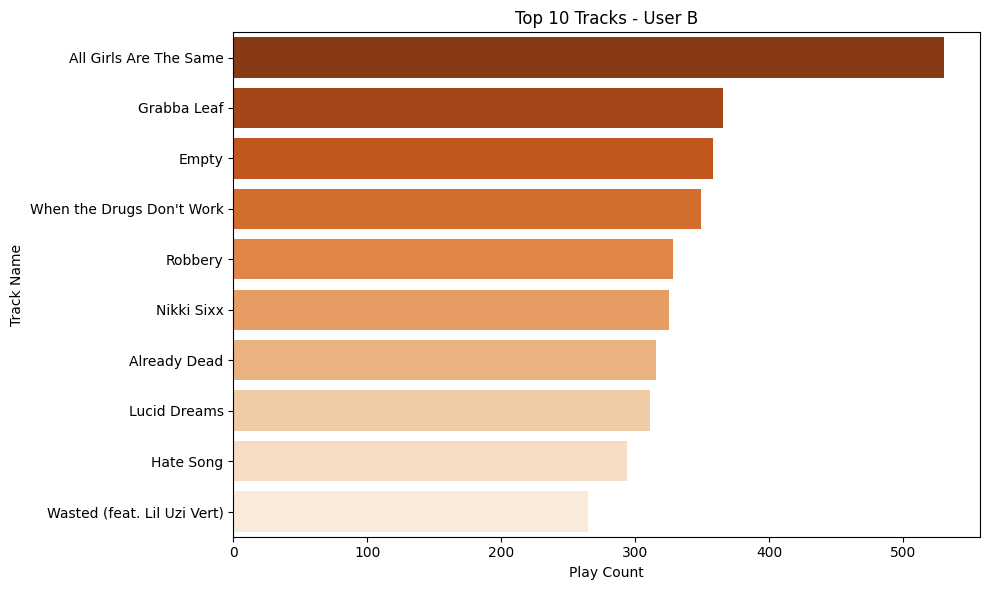

In [49]:
#Top 10 Tracks
#Top 10 tracks for each user
top_tracks_a = df_a['master_metadata_track_name'].value_counts().head(10)
top_tracks_b = df_b['master_metadata_track_name'].value_counts().head(10)

#Plot for User A
plt.figure(figsize=(10,6))
sns.barplot(x=top_tracks_a.values, y=top_tracks_a.index, palette='Blues_r')
plt.title("Top 10 Tracks - User A")
plt.xlabel("Play Count")
plt.ylabel("Track Name")
plt.tight_layout()
plt.show()

#Plot for User B
plt.figure(figsize=(10,6))
sns.barplot(x=top_tracks_b.values, y=top_tracks_b.index, palette='Oranges_r')
plt.title("Top 10 Tracks - User B")
plt.xlabel("Play Count")
plt.ylabel("Track Name")
plt.tight_layout()
plt.show()

C:\Users\lynnm\AppData\Local\Temp\ipykernel_1596\2284149838.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists_a.values, y=top_artists_a.index, palette='Blues_r')


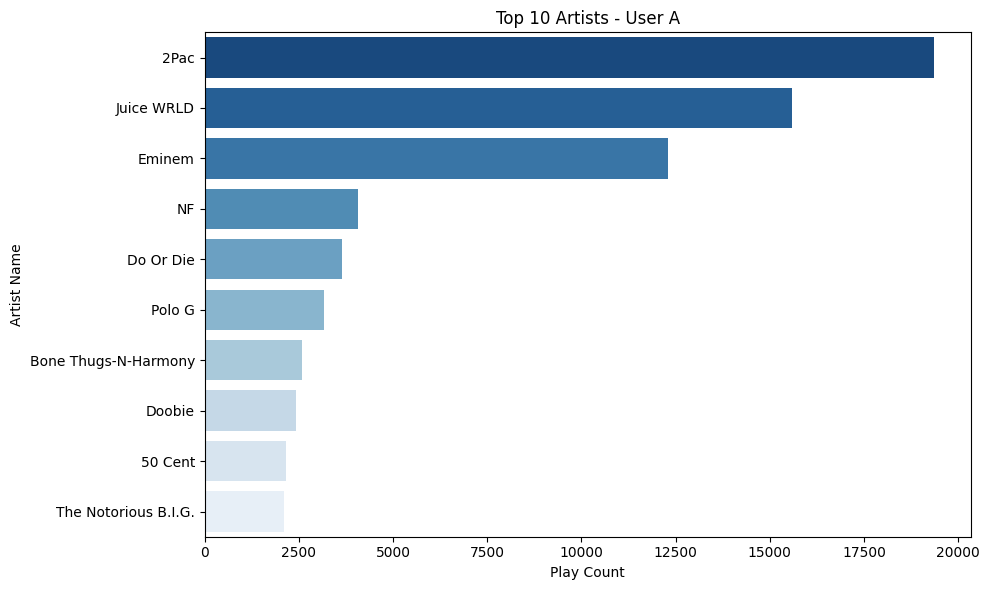

C:\Users\lynnm\AppData\Local\Temp\ipykernel_1596\2284149838.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists_b.values, y=top_artists_b.index, palette='Oranges_r')


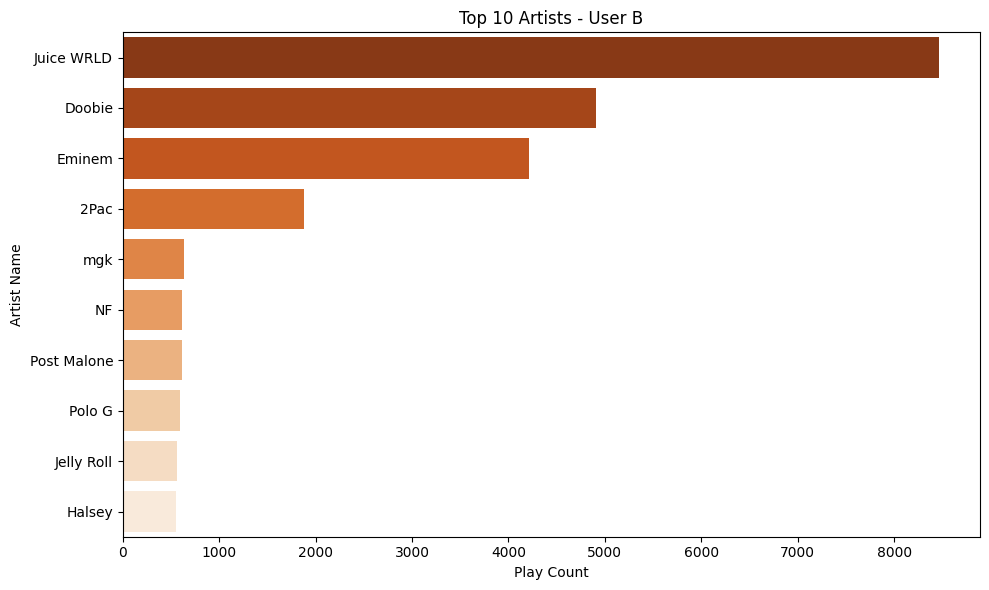

In [50]:
#Top 10 artists
top_artists_a = df_a['master_metadata_album_artist_name'].value_counts().head(10)
top_artists_b = df_b['master_metadata_album_artist_name'].value_counts().head(10)

#User A
plt.figure(figsize=(10,6))
sns.barplot(x=top_artists_a.values, y=top_artists_a.index, palette='Blues_r')
plt.title("Top 10 Artists - User A")
plt.xlabel("Play Count")
plt.ylabel("Artist Name")
plt.tight_layout()
plt.show()

#User B
plt.figure(figsize=(10,6))
sns.barplot(x=top_artists_b.values, y=top_artists_b.index, palette='Oranges_r')
plt.title("Top 10 Artists - User B")
plt.xlabel("Play Count")
plt.ylabel("Artist Name")
plt.tight_layout()
plt.show()

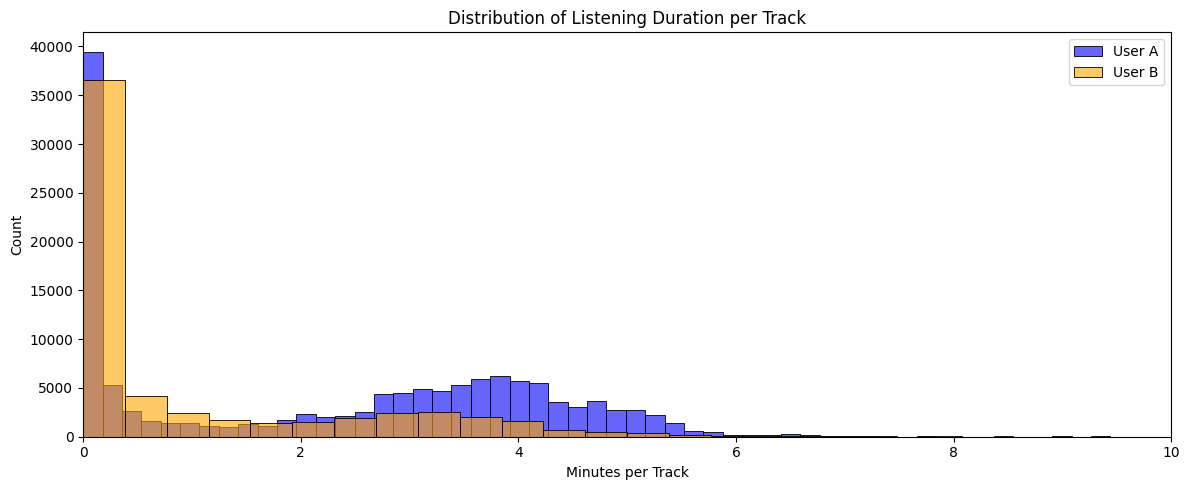

In [51]:
#Listening Duration per Track
#Convert ms to minutes (60000)
df_a['minutes_played'] = df_a['ms_played'] / 60000
df_b['minutes_played'] = df_b['ms_played'] / 60000

#Histograms
plt.figure(figsize=(12,5))
sns.histplot(df_a['minutes_played'], bins=100, color='blue', label='User A', alpha=0.6)
sns.histplot(df_b['minutes_played'], bins=100, color='orange', label='User B', alpha=0.6)
plt.xlim(0, 10)  # focus on 0-10 min tracks
plt.xlabel("Minutes per Track")
plt.ylabel("Count")
plt.title("Distribution of Listening Duration per Track")
plt.legend()
plt.tight_layout()
plt.show()

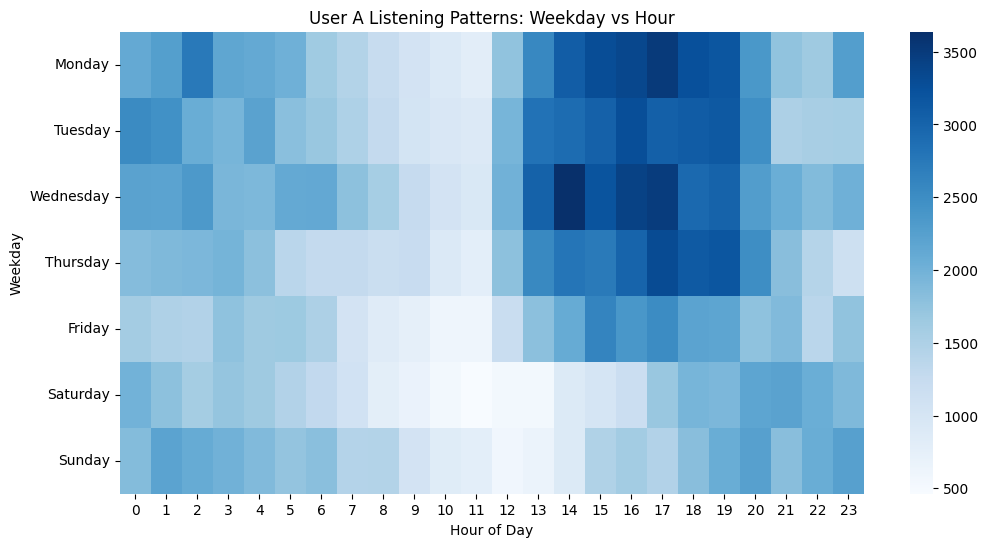

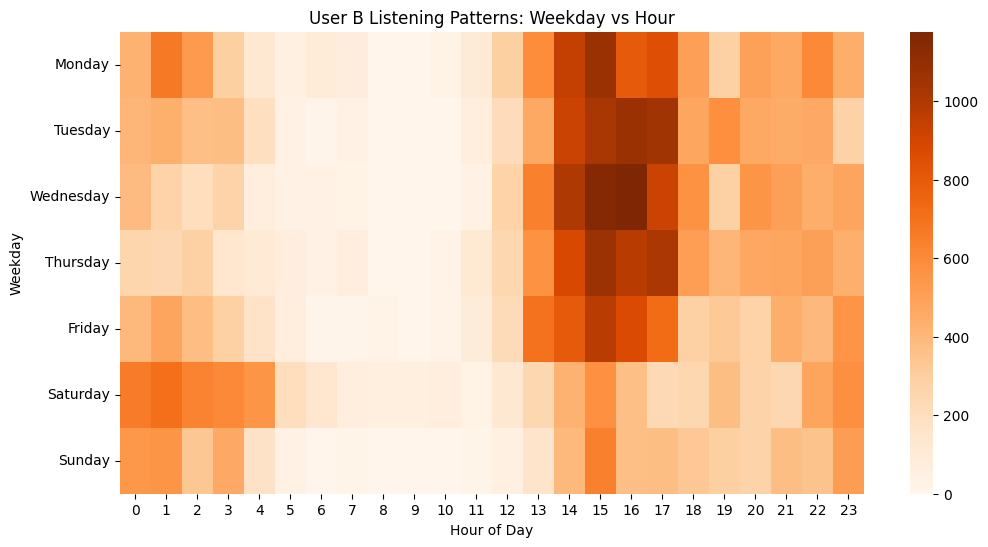

In [52]:
#Extract hour and weekday
df_a['hour'] = df_a['ts'].dt.hour
df_a['weekday'] = df_a['ts'].dt.day_name()

df_b['hour'] = df_b['ts'].dt.hour
df_b['weekday'] = df_b['ts'].dt.day_name()

#Pivot table for heatmap
heatmap_a = df_a.pivot_table(index='weekday', columns='hour', values='minutes_played', aggfunc='sum').fillna(0)
heatmap_b = df_b.pivot_table(index='weekday', columns='hour', values='minutes_played', aggfunc='sum').fillna(0)

#Reorder weekdays
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_a = heatmap_a.reindex(order)
heatmap_b = heatmap_b.reindex(order)

#User A heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_a, cmap='Blues')
plt.title("User A Listening Patterns: Weekday vs Hour")
plt.ylabel("Weekday")
plt.xlabel("Hour of Day")
plt.show()

#User B heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_b, cmap='Oranges')
plt.title("User B Listening Patterns: Weekday vs Hour")
plt.ylabel("Weekday")
plt.xlabel("Hour of Day")
plt.show()